# FAME Database Inspection & Auditing Tools
This notebook provides a suite of tools to quickly audit, sample, and query the compiled FAME DuckDB database.

It uses `Ibis` to push computations directly to DuckDB, meaning queries execute in milliseconds and use almost zero Python memory.

In [1]:
from pathlib import Path
from dataclasses import dataclass
import os
import sys
from dotenv import load_dotenv

table_name = "fame_data- v remote.duckdb"

# Add .env's PYTHONPATH to sys.path
load_dotenv(override=True)
PYTHONPATH = os.getenv("PYTHONPATH")
if PYTHONPATH is not None:
    if PYTHONPATH not in sys.path:
        print(f"Adding {PYTHONPATH} to sys.path")
        sys.path.append(PYTHONPATH)

# Define the structure clearly
@dataclass
class Dirs:
    data_dir: Path = None       # type: ignore
    output_dir: Path = None     # type: ignore
    input_dir: Path = None      # type: ignore
    db_path: Path = None         # type: ignore
dirs = Dirs()

try:
    from utils.f_0_dirs import get_data_dirs
    dirs = get_data_dirs()
    # raise ImportError("Testing ImportError for demonstration purposes") 

# For easy access purposes, if this script is run directly in a folder with the databases
# and without the dir import modules, then just set it to current_dir
except ImportError as e:
    print(f"ImportError: {e}")
    try:
        current_dir = Path(__file__).parent
    except NameError:
        current_dir = Path.cwd()
    dirs = Dirs(
        output_dir=current_dir,
        data_dir=current_dir,
        input_dir=current_dir,
        db_path=current_dir / table_name
    )

for attr in dir(dirs):
    if attr.startswith('_'):
        continue
    if callable(getattr(dirs, attr)):
        continue
    print(f"{attr}: {getattr(dirs, attr)}")

data_dir: D:\FAME - LN dataset\Dropbox\fame_clean\2_clean_FAME_data
db_path: C:\Users\lazyst\Files\ucl\Dissertation\build\output\fame_data.duckdb
input_dir: C:\Users\lazyst\Files\ucl\Dissertation\build\input
output_dir: C:\Users\lazyst\Files\ucl\Dissertation\build\output
raw_data_dir: D:\FAME - LN dataset\Dropbox\fame_clean\1_FAME_raw_data\2025.02
root_data_dir: D:\FAME - LN dataset\Dropbox\fame_clean
root_dir: C:\Users\lazyst\Files\ucl\Dissertation
tmp_dir: C:\Users\lazyst\Files\ucl\Dissertation\build\tmp
work_dir: C:\Users\lazyst\Files\ucl\Dissertation\build\src


In [2]:
import pandas as pd
import ibis
import ibis.selectors as s

# 1. Setup paths
db_path = dirs.output_dir / "fame_data.duckdb"
# if db_path != dirs.db_path:
#     raise ValueError(f"db_path {db_path} does not match dirs.db_path {dirs.db_path}")

# 2. Connect to the database
con = ibis.duckdb.connect(db_path, read_only=True)

# 3. Configure Pandas display for easier reading
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 50)

print(f"🖧 Successfully connected to: {db_path}")
print(con.list_tables())

🖧 Successfully connected to: C:\Users\lazyst\Files\ucl\Dissertation\build\output\fame_data.duckdb
['fame_fixed_filtered', 'fame_yearly_kp', 'ref_ons_postcode', 'ref_ons_ttwa_name', 'working_distance_ttwa_km', 'working_fixed', 'working_yearly', 'working_yearly_g', 'working_yearly_n']


In [3]:
import ibis

out_file = dirs.output_dir / "duckdb_tables.md"
con = ibis.duckdb.connect(db_path, read_only=True)
interesting_tables = [
    # "fame_fixed", "fame_yearly",
    "fame_fixed_filtered", "fame_yearly_kp",
    "working_fixed", "working_yearly",
    "working_yearly_g", "working_yearly_n",
    # "working_yearly_with_peers", "working_yearly_with_tfp_wave", "working_distance_pc_",
    "working_distance_ttwa_km",
    "ref_ons_postcode", "ref_ons_ttwa_name"
    # "lars_fixed", "lars_yearly",
]
existing_tables = con.list_tables()
print(f"Existing tables in the database: {existing_tables}")
# Intersection of 2 lists
intersection = [table for table in interesting_tables if table in existing_tables]

with open(out_file, "w") as f:
    f.write("# Tables in DuckDB database\n\n")
    for table in intersection:
        f.write(f"## {table}\n\n")
        f.write(f"### Number of rows: {con.table(table).count().execute():,}\n\n")
        f.write(f"### Schema:\n\n```\n{con.table(table).schema()}\n```\n\n")
        f.write(f"### Head of table:\n\n```\n{con.table(table).head().execute()}\n```\n\n")
print(f"📔 Successfully listed tables and their heads in: {out_file}")

Existing tables in the database: ['fame_fixed_filtered', 'fame_yearly_kp', 'ref_ons_postcode', 'ref_ons_ttwa_name', 'working_distance_ttwa_km', 'working_fixed', 'working_yearly', 'working_yearly_g', 'working_yearly_n']
📔 Successfully listed tables and their heads in: C:\Users\lazyst\Files\ucl\Dissertation\build\output\duckdb_tables.md


### Output and drop other tables

In [4]:
# List all tables and their number of rows in the database that are not in the interesting_tables list
existing_tables = con.list_tables()
exclusion = set(existing_tables) - set(interesting_tables)
out_file = dirs.output_dir / "duckdb_other_tables.md"
print(f"Uninteresting tables: {exclusion}")
with open(out_file, "w") as f:
    f.write("# Other Tables in DuckDB database\n\n")
    for table in exclusion:
        try:
            nb_rows = con.table(table).count().execute()
            f.write(f"## {table}\n\n")
            f.write(f"### Number of rows: {nb_rows:,}\n\n")
            f.write(f"### Schema:\n\n```\n{con.table(table).schema()}\n```\n\n")
            # f.write(f"### Head of table:\n\n```\n{con.table(table).head().execute()}\n```\n\n")
        except Exception as e:
            print(f"Error processing table {table}: {e}")
print(f"📔 Successfully listed other tables and their heads in: {out_file}")

Uninteresting tables: set()
📔 Successfully listed other tables and their heads in: C:\Users\lazyst\Files\ucl\Dissertation\build\output\duckdb_other_tables.md


In [5]:
%%script NO
con.disconnect()
con_write = ibis.duckdb.connect(dirs.db_path)
con_write.list_tables()
keep_tables = [] + interesting_tables
# Try and drop all other tables in the database that are not in the keep_tables list

# List the tables in exclusion, and then prompt the user to y/n confirm dropping those table names as a console input
print(f"Tables to be dropped: {exclusion - set(keep_tables)}")
user_input = input("Do you want to drop these tables? (y/n): ")
if user_input.lower() != 'y':
    print("Aborting table drop operation.")
else:
    for table_name in exclusion:
        if table_name in keep_tables:
            continue
        try:
            table = con_write.table(table_name)
            print(f"🗑️ Dropping table: {table_name} with {table.count().execute():,} rows")
            con_write.drop_table(table_name)
        except Exception as e:
            print(f"⚠️ Failed to drop table {table_name}: {e}")
            try:
                print(f"🗑️ Attempting to drop view: {table_name}")
                con_write.drop_view(table_name)  # Attempt to drop view if it exists
            except Exception as e:
                print(f"❌ Failed to handle {table_name} as both table and view: {e}")
    existing_tables = con_write.list_tables()
    exclusion = set(existing_tables) - set(interesting_tables)
    print(exclusion)


Couldn't find program: 'NO'


## 1. High-Level Database Overview
Quickly check which tables exist in the database and their total row counts.

In [6]:
tables = con.list_tables()
print("📊 Database Tables Overview:\n" + "-"*30)

for table_name in tables:
    t = con.table(table_name)
    # Fast row counting pushed down to DuckDB
    row_count = t.count().execute()
    col_count = len(t.columns)
    print(f"[{table_name}]")
    print(f"   Rows: {row_count:,} | Columns: {col_count}")
print("-" * 30)

📊 Database Tables Overview:
------------------------------
[extended_yearly]
   Rows: 1,096,814 | Columns: 18
[fame_fixed_filtered]
   Rows: 152,379 | Columns: 31
[fame_yearly_kp]
   Rows: 1,128,490 | Columns: 37
[ibis_duckdb_table_mbmpdieumjarxgal4t4h2zrdvi]
   Rows: 0 | Columns: 32
[ibis_duckdb_table_qvdxvlfmgvcqfkexflhpga3c54]
   Rows: 0 | Columns: 23
[ibis_duckdb_table_uy5fkpuzaven5jgbbqrlcmecju]
   Rows: 0 | Columns: 23
[ibis_duckdb_table_zgasyjxqozadxdj6grwhs5wzsy]
   Rows: 0 | Columns: 14
[ref_ons_postcode]
   Rows: 2,726,477 | Columns: 4
[ref_ons_ttwa_name]
   Rows: 230 | Columns: 2
[spatial_panel_view]
   Rows: 1,081,520 | Columns: 26
[temp_random_peers]
   Rows: 180 | Columns: 13
[temp_spatial_pairs]
   Rows: 184 | Columns: 6
[working_distance_pc_]
   Rows: 43,241,404 | Columns: 4
[working_distance_ttwa_km]
   Rows: 734,346,954 | Columns: 3
[working_fixed]
   Rows: 152,379 | Columns: 15
[working_yearly]
   Rows: 1,128,490 | Columns: 11
[working_yearly_g]
   Rows: 1,045,164 | 

## 3. Specific Lookup

### Firm-specific (Search by Name or ID)
Find all fixed and derived attributes for a specific company using partial string matching (case-insensitive).

In [7]:
search_term = "Decathlon"  # Can be a partial name or a Registered Number
table_fixed = con.table("fame_fixed")

# Filter where company_name contains the search term OR exactly matches registered_number
search_query = table_fixed.filter(
    table_fixed["company_name"].upper().contains(search_term.upper()) |
    (table_fixed["registered_number"] == search_term)
)

# Pull the top 5 matches
df_search_results = search_query.head(20).execute()

print(f"🔍 Top search results for '{search_term}':")
display(df_search_results[["registered_number", "company_name", "ro_address", "primary_trading_address"]])

TableNotFound: fame_fixed

### Industry-specific (by 2-digit SIC or 6-digit
- 6-digit using primary_uk_sic_2007_code in fame_fixed

In [ ]:
# ### Industry-specific (by 2-digit SIC or 6-digit
# - 6-digit using primary_uk_sic_2007_code in fame_fixed
import json
import ibis
import pandas as pd

# Read build/input/SIC_priorities.json
search_inds = []
search_table = "fame_fixed_filtered"
additional_tables = ["working_yearly"]

get_from_json = False
if get_from_json:
    with open(dirs.input_dir / "SIC_priorities.json", "r") as f:
        sic_priorities = json.load(f)
        search_inds = [entry.get("Division") for entry in sic_priorities if entry.get("Errored") == True]
else:
    search_inds = ["70", "74"]

# Ensure strings are properly formatted (e.g. padded with zeros) just in case
search_inds_str = [str(x).zfill(2) for x in search_inds if x is not None]
print(f"Searching for following SIC divisions individually: {search_inds_str}")

# Connect to the tables in the database
# TODO: search for industries without fame_derived
t_fixed = con.table(search_table)

# List to accumulate our row records
results = []

for ind in search_inds_str:
    # 1. Filter the fame_fixed table for the specific SIC division
    regex_pattern = rf'\b{ind}\b'
    filtered_fixed = t_fixed.filter(
        t_fixed.industry_codes.re_search(regex_pattern)
    )
    fixed_count = filtered_fixed.count().execute()

    # Append the counts for this specific division to our results list
    results_obj = {
        "SIC_Division": ind
    }
    results_obj[search_table] = fixed_count

    # 3. For every additional table, filter using a semi-join and count the matches
    for table_name in additional_tables:
        t_additional = con.table(table_name)
        additional_count = t_additional.semi_join(filtered_fixed, "registered_number").count().execute()
        results_obj[table_name] = additional_count

    results.append(results_obj)

# Output the results as a formatted table
output_table = pd.DataFrame(results)

print("📊 Matching Rows by Table for Each SIC Division:")
display(output_table) # use print(output_table) if you aren't in a Jupyter environment

Searching for following SIC divisions individually: ['70', '74']
📊 Matching Rows by Table for Each SIC Division:


,SIC_Division,fame_fixed_filtered,working_yearly
0,70,14004,93192
1,74,2758,19155


## 5. Summary Statistics & Aggregations
Generate high-level analytical cuts (e.g., counting the number of records per year, or assessing data coverage).

In [ ]:
t_yearly = con.table("fame_yearly")

# Aggregate the number of financial records available per year
# Print numbers of available records for every financial column
yearly_distribution = (
    t_yearly
    .group_by("year")
    .aggregate(
        turnover=t_yearly["turnover"].count(),
        pnl=t_yearly["profit_loss_pretax"].count(),
        employees=t_yearly["employees"].count(),
        tangibles=t_yearly["tangibles"].count(),
        t_lab=t_yearly["tangibles_land_and_buildings"].count(),
        t_land_free=t_yearly["tangibles_land_freehold"].count(),
        t_land_lease=t_yearly["tangibles_land_leasehold"].count(),
        fixed_other=t_yearly["fixed_other"].count(),
        intangibles=t_yearly["intangibles"].count(),
        fixed_total=t_yearly["fixed_total"].count(),
        liabilities=t_yearly["liabilities"].count(),
        t_assets=t_yearly["total_assets"].count(),
        liabilites_lt=t_yearly["liabilites_lt"].count(),
        cos=t_yearly["cos"].count(),
        dividends=t_yearly["dividends"].count(),
        r_and_d=t_yearly["r_and_d"].count(),
        renum=t_yearly["remuneration_employees"].count(),
        wages=t_yearly["wages"].count(),
        ss_cost=t_yearly["social_security_costs"].count(),
        pension_cost=t_yearly["pensions_costs"].count(),
        ebitda=t_yearly["ebitda"].count(),
        all=t_yearly.count()
    )
    .order_by(ibis.desc("year"))
)

print("📈 Data coverage by year:")
# Format table with commas for readability and display
count_table: pd.DataFrame = yearly_distribution.execute()
count_table_formatted = count_table.copy().reset_index(drop=True)
for col in count_table_formatted.columns:
    if col != "year":
        count_table_formatted[col] = count_table_formatted[col].apply(lambda x: f"{x:,}")
display(count_table_formatted)

📈 Data coverage by year:


,year,turnover,pnl,employees,tangibles,t_lab,t_land_free,t_land_lease,fixed_other,intangibles,fixed_total,liabilities,t_assets,liabilites_lt,cos,dividends,r_and_d,renum,wages,ss_cost,pension_cost,ebitda,all
0,2025,759,860,"8,735","7,782",431,306,140,"5,644",478,"10,916","12,206","18,063","5,970",1,0,0,0,0,0,0,2,"23,662"
1,2024,"87,248","98,126","1,278,115","993,775","98,455","80,144","22,311","685,755","59,488","1,199,578","1,454,312","1,796,835","776,575","35,793","12,710","1,327","51,970","38,616","32,033","33,235","100,458","1,981,608"
2,2023,"194,129","228,967","2,288,462","1,880,076","209,875","164,680","54,497","1,282,932","137,487","2,292,221","2,773,692","3,413,902","1,526,315","92,766","32,452","4,957","114,014","92,169","79,274","80,959","224,297","3,528,552"
3,2022,"192,850","228,319","2,237,681","1,838,108","206,455","160,718","55,359","1,257,407","138,225","2,233,739","2,709,182","3,333,356","1,504,295","91,786","31,186","4,933","111,055","89,145","77,405","78,771","223,253","3,442,519"
4,2021,"190,673","225,472","2,168,934","1,783,334","199,035","153,975","54,175","1,214,968","138,388","2,151,847","2,639,500","3,229,526","1,461,349","89,356","29,813","4,664","110,399","87,956","75,683","76,652","220,646","3,330,718"
5,2020,"192,145","225,077","2,070,377","1,707,243","196,249","152,776","52,812","1,165,875","137,839","2,036,234","2,549,355","3,073,513","1,218,218","89,437","30,639","4,696","108,421","92,686","74,936","74,983","220,176","3,167,684"
6,2019,"194,756","225,119","1,512,079","1,626,565","204,953","165,672","50,206","1,139,826","138,402","1,931,645","2,424,907","2,913,704","995,232","90,232","34,693","4,601","105,208","104,368","73,191","71,081","220,082","2,998,462"
7,2018,"197,953","227,983","1,252,970","1,566,977","205,504","166,575","50,002","1,074,368","141,327","1,848,785","2,309,065","2,773,457","940,907","93,524","38,252","4,600","106,056","105,951","72,526","69,111","223,702","2,848,099"
8,2017,"211,329","243,277","1,048,998","1,513,100","203,633","165,547","48,810","1,027,649","149,013","1,756,682","2,221,153","2,654,750","885,527","99,774","42,857","4,628","111,674","111,569","73,364","66,249","238,764","2,721,724"
9,2016,"195,732","218,672","535,221","1,448,753","97,043","72,752","32,402","1,284,240","191,618","1,685,343","2,102,045","2,509,869","769,259","99,740","48,756","3,597","101,439","101,271","75,797","61,962","213,829","2,566,936"


## 6. Exporting Queries to Excel
Any queried subset of data can be instantly dumped into an Excel file for offline review.

In [5]:
import pandas as pd
import ibis

approach = 'random' # first

# Dump a random sample of 500 rows from each table to a single .xlsx file in /tmp
row_count = 2000
out_file_raw = dirs.output_dir / "df_raw_sample.xlsx"
out_tables = set(interesting_tables)
exists_tables = con.list_tables()
intersection = set(out_tables).intersection(exists_tables)

# but we want to have 5 separate tabs in the same excel file, one for each table, with the table name as the tab name
con = ibis.duckdb.connect(db_path, read_only=True)
with pd.ExcelWriter(out_file_raw, engine='openpyxl') as writer:
    # df_raw_head.to_excel(writer, sheet_name='df_raw', index=False)
    for table_name in intersection:
        if approach == 'first':
            con.table(table_name).head(row_count).execute().to_excel(writer, sheet_name=table_name, index=False)
        elif approach == 'random':
            df_table_rd = (
                con.table(table_name)
                .order_by(ibis.random.rand())
                .limit(row_count)
                .execute()
            )
            df_table_rd.to_excel(writer, sheet_name=table_name, index=False)
        
print(f"✅ Successfully dumped a random {row_count} rows of df_raw to: {out_file_raw}")

✅ Successfully dumped a random 2000 rows of df_raw to: C:\Users\lazyst\Files\ucl\Dissertation\build\output\df_raw_sample.xlsx


# 7. Industry counts in each of the tables
### [read] Count cells belong to certain industries
- Using the fame_derived system
- Remove rows belonging to a certain industry, as a 'fresh start' mechanism

📊 Industry Codes and Their Counts:
Industry Code: 01, Count: 950
Industry Code: 02, Count: 121
Industry Code: 03, Count: 88
Industry Code: 05, Count: 52
Industry Code: 06, Count: 289
Industry Code: 07, Count: 89
Industry Code: 08, Count: 356
Industry Code: 09, Count: 465
Industry Code: 10, Count: 2,102
Industry Code: 11, Count: 365
Industry Code: 12, Count: 25
Industry Code: 13, Count: 485
Industry Code: 14, Count: 359
Industry Code: 15, Count: 73
Industry Code: 16, Count: 456
Industry Code: 17, Count: 572
Industry Code: 18, Count: 906
Industry Code: 19, Count: 68
Industry Code: 20, Count: 1,117
Industry Code: 21, Count: 419
Industry Code: 22, Count: 1,320
Industry Code: 23, Count: 598
Industry Code: 24, Count: 527
Industry Code: 25, Count: 2,787
Industry Code: 26, Count: 1,420
Industry Code: 27, Count: 1,046
Industry Code: 28, Count: 1,784
Industry Code: 29, Count: 575
Industry Code: 30, Count: 457
Industry Code: 31, Count: 583
Industry Code: 32, Count: 2,857
Industry Code: 33, Count:

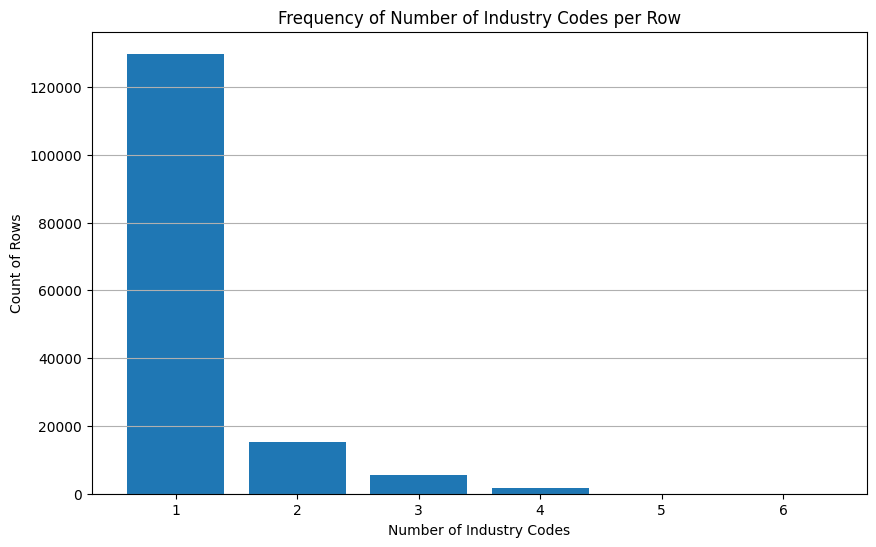

In [ ]:
# connect to fame_derived and group by industry_codes
# count the number of rows belonging to each group (unique industry_codes)
# Sort the results in ascending order of industry_codes
# Output the result (as a table, with counts as the column)
import ibis
from ibis import _
import matplotlib.pyplot as plt
from utils.f_0_dirs import get_data_dirs

dirs = get_data_dirs()
con = ibis.duckdb.connect(db_path, read_only=True)
fame_derived = con.table("fame_fixed_filtered")

# industry_codes are a comma-separated string of codes
# as each row could have multiple industry values
# Within SQL, separate them, and then count each unique value.
industry_counts_one = (
    fame_derived.mutate(industry_codes_split=fame_derived.industry_codes.split(","))
    .unnest("industry_codes_split")
    .group_by("industry_codes_split")
    .aggregate(count=_.count())
    .order_by("industry_codes_split")
)

# Additionally, we want to see how many rows have just 1 industry code, 2, 3 etc.
industry_counts_freq = (
    fame_derived.mutate(industry_codes_count=fame_derived.industry_codes.split(",").length())
    .group_by("industry_codes_count")
    .aggregate(count=_.count())
    .order_by("industry_codes_count")
)

# Execute and display the results
print("📊 Industry Codes and Their Counts:")
df_industry_counts = industry_counts_one.execute()
for index, row in df_industry_counts.iterrows():
    print(f"Industry Code: {row['industry_codes_split']}, Count: {row['count']:,}")

print("📊 Frequency of Number of Industry Codes per Row:")
df_industry_counts_freq = industry_counts_freq.execute()
for index, row in df_industry_counts_freq.iterrows():
    print(f"Number of Industry Codes: {row['industry_codes_count']}, Count: {row['count']:,}")
plt.figure(figsize=(10, 6))
plt.bar(df_industry_counts_freq['industry_codes_count'], df_industry_counts_freq['count'])
plt.xlabel('Number of Industry Codes')
plt.ylabel('Count of Rows')
plt.title('Frequency of Number of Industry Codes per Row')
plt.xticks(df_industry_counts_freq['industry_codes_count'])
plt.grid(axis='y')
plt.show()

### 8. Count number of rows with duplicates

📊 Registered number count


,count,num_registered_numbers,percent
0,1,144841,97.574137
1,2,3288,2.215007
2,3,290,0.195362
3,4,23,0.015494


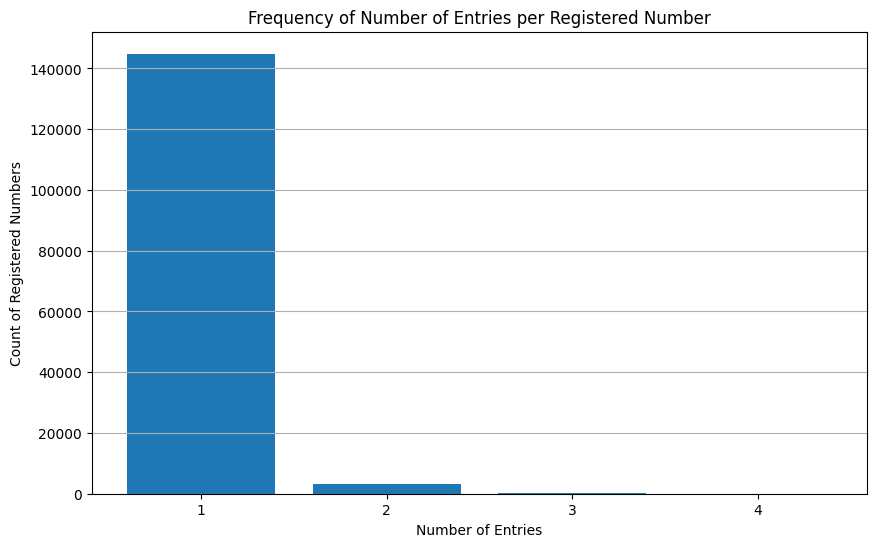

In [ ]:
table_name = "working_fixed"
fame_derived = con.table(table_name)

# Group by registered_number
# Count the number of entries that are unique (1 matching row) for their respective registered_number
# And number of entries that have 2, 3, 4 etc. matching rows
rn_count = (
    fame_derived
    .group_by("registered_number")
    .aggregate(count=_.count())
    .group_by("count")
    .aggregate(num_registered_numbers=_.count())
    .order_by("count")
    .mutate(
        total_registered_numbers=_.num_registered_numbers.sum()
    )
    .mutate(
        percent=(_.num_registered_numbers / _.total_registered_numbers * 100)
    )
    .drop("total_registered_numbers")
)

# Execute and display the results
df_rn_count = rn_count.execute()
print("📊 Registered number count")
display(df_rn_count)

plt.figure(figsize=(10, 6))
plt.bar(df_rn_count['count'], df_rn_count['num_registered_numbers'])
plt.xlabel('Number of Entries')
plt.ylabel('Count of Registered Numbers')
plt.title('Frequency of Number of Entries per Registered Number')
plt.xticks(df_rn_count['count'])
plt.grid(axis='y')
plt.show()

In [ ]:
# import ibis
# from utils.f_0_dirs import get_data_dirs
# db_path = get_data_dirs().output_dir / "fame_data.duckdb"
# con = ibis.duckdb.connect(db_path)

con.raw_sql("CHECKPOINT;")
con.disconnect()